In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

In [3]:
# create dataset
X,y=make_moons(n_samples=600, noise=0.25, random_state=42)
X_train, X_test, y_train, y_test=train_test_split(
    X, y, test_size=0.3, random_state=42
)

In [5]:
# Pre-pruning (early stopping)
# train trees with different depths
depths=list(range(1,15))
train_acc_pre=[]
test_acc_pre=[]

for d in depths:
    tree=DecisionTreeClassifier(
        max_depth=d,    # pre-pruning control
        min_samples_leaf=5,   # another pre-pruning control
        random_state=42
    )

    tree.fit(X_train, y_train)

    train_acc_pre.append(accuracy_score(y_train, tree.predict(X_train)))
    test_acc_pre.append(accuracy_score(y_test, tree.predict(X_test)))

test_acc_pre

[0.8111111111111111,
 0.8888888888888888,
 0.8888888888888888,
 0.8888888888888888,
 0.9,
 0.9,
 0.9,
 0.9,
 0.9,
 0.9,
 0.9,
 0.9,
 0.9,
 0.9]

In [6]:
# POST-PRUNING (Cost Complexity Pruning)
full_tree = DecisionTreeClassifier(random_state=42)
full_tree.fit(X_train, y_train)

# Compute pruning path
path = full_tree.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas = path.ccp_alphas    # cost complexity pruning

train_acc_post = []
test_acc_post = []

for alpha in ccp_alphas:
    pruned_tree = DecisionTreeClassifier(
        ccp_alpha=alpha,
        random_state=42
    )

    pruned_tree.fit(X_train, y_train)

    train_acc_post.append(
        accuracy_score(y_train, pruned_tree.predict(X_train))
    )

    test_acc_post.append(
        accuracy_score(y_test, pruned_tree.predict(X_test))
    )

test_acc_post

[0.9055555555555556,
 0.9055555555555556,
 0.9055555555555556,
 0.9055555555555556,
 0.9055555555555556,
 0.9111111111111111,
 0.9111111111111111,
 0.9,
 0.9055555555555556,
 0.8888888888888888,
 0.9,
 0.9,
 0.9055555555555556,
 0.8888888888888888,
 0.8611111111111112,
 0.8111111111111111,
 0.49444444444444446]

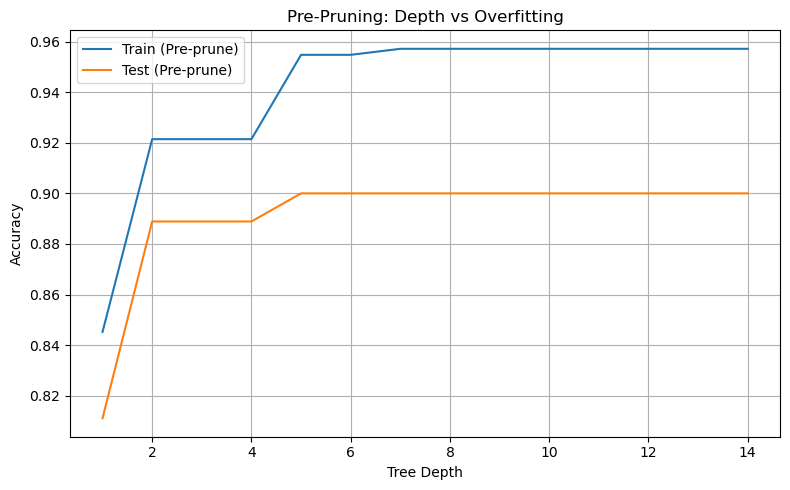

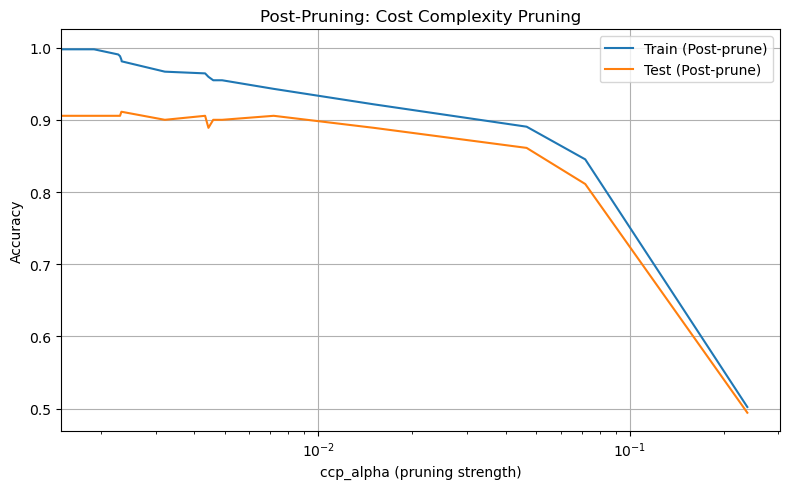

In [7]:
# plot results
plt.figure(figsize=(8,5))
plt.plot(depths, train_acc_pre, label="Train (Pre-prune)")
plt.plot(depths, test_acc_pre, label="Test (Pre-prune)")
plt.xlabel("Tree Depth")
plt.ylabel("Accuracy")
plt.title("Pre-Pruning: Depth vs Overfitting")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8,5))
plt.plot(ccp_alphas, train_acc_post, label="Train (Post-prune)")
plt.plot(ccp_alphas, test_acc_post, label="Test (Post-prune)")
plt.xscale("log")
plt.xlabel("ccp_alpha (pruning strength)")
plt.ylabel("Accuracy")
plt.title("Post-Pruning: Cost Complexity Pruning")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [8]:
# Key takeaway for students
best_alpha = ccp_alphas[np.argmax(test_acc_post)]
print(f"\nBest ccp_alpha based on test accuracy: {best_alpha:.6f}")
print("- Larger ccp_alpha = more aggressive pruning.")


Best ccp_alpha based on test accuracy: 0.002331
- Larger ccp_alpha = more aggressive pruning.
